In [1]:
!pip install transformer_lens==2.18.0 sae_lens

In [2]:
import torch
import numpy as np
from transformer_lens import HookedTransformer
from sae_lens import SAE
from functools import partial
import json
import torch
import gc

torch.set_grad_enabled(False)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
def empty_cache():
  gc.collect()
  torch.cuda.empty_cache()

In [4]:
empty_cache()

In [5]:
from huggingface_hub import login
login()

In [6]:
MODEL_NAME = "gemma-2-2b"
DEVICE = "cuda"
DTYPE = torch.float16
SAE_RELEASE = "gemma-scope-2b-pt-res-canonical"
SAE_ID = "layer_{LAYER}/width_16k/canonical"
HOOK_NAME = "blocks.{LAYER}.hook_resid_post"


In [7]:
model = HookedTransformer.from_pretrained(
        MODEL_NAME,
        device=DEVICE,
        dtype=DTYPE,
        device_map="auto",
        center_writing_weights=False,
        center_unembed=False,
        fold_ln=False,
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model gemma-2-2b into HookedTransformer


In [9]:
def _sae(layer):
  return SAE.from_pretrained(
        release=SAE_RELEASE,
        sae_id=SAE_ID.replace("{LAYER}", str(layer)),
        device=DEVICE,
    )

In [8]:
def get_mean_feature_activations(
    texts: list[str],
    model: HookedTransformer,
    sae: SAE,
    hook_name: str,
) -> torch.Tensor:

    all_feature_acts = []

    for text in texts:
        _, cache = model.run_with_cache(
            text,
            prepend_bos=True,
            names_filter=[hook_name],
        )

        activations = cache[hook_name]
        feature_acts = sae.encode(activations.to(sae.device))
        mean_acts = feature_acts.mean(dim=[0, 1])
        all_feature_acts.append(mean_acts)

        del cache, activations, feature_acts
        torch.cuda.empty_cache()

    return torch.stack(all_feature_acts).mean(dim=0)

In [10]:
def calculate_features(concept_prompts, baseline_prompts, sae, hook_name):
    concept_acts = get_mean_feature_activations(
        concept_prompts, model, sae, hook_name
    )
    baseline_acts = get_mean_feature_activations(
        baseline_prompts, model, sae, hook_name
    )

    specificity = concept_acts - baseline_acts

    empty_cache()
    return specificity, concept_acts, baseline_acts

In [11]:
import matplotlib.pyplot as plt
import os
from datetime import datetime

def plot_top_feats_dist(
    specificity,
    concept_acts,
    baseline_acts,
    layer,
    top_n=10,
    save_dir="plots",
    save=True
):
    os.makedirs(save_dir, exist_ok=True)

    top_n_indices = torch.argsort(specificity, descending=True)[:top_n]
    top_n_labels = [str(idx.item()) for idx in top_n_indices]

    datasets = [
        ("Średnie aktywacje cech dla konceptu", concept_acts, "seagreen"),
        ("Średnie aktywacje cech dla zbioru bazowego", baseline_acts, "coral"),
        ("Różnica aktywacji", specificity, "steelblue"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Średni rozkład aktywacji cech dla warstwy {str(layer)}", fontsize=14)

    for ax, (subtitle, data, color) in zip(axes, datasets):
        values = data[top_n_indices].cpu().numpy()

        ax.bar(range(top_n), values, color=color)
        ax.set_xticks(range(top_n))
        ax.set_xticklabels(top_n_labels, rotation=45, ha="right")
        ax.set_xlabel("Indeks cechy")
        ax.set_ylabel("Wartość aktywacji")
        ax.set_title(subtitle)

        for i, v in enumerate(values):
            ax.text(i, v + 0.002, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"layer_{layer}_{timestamp}.png"
    filepath = os.path.join(save_dir, filename)

    fig.savefig(filepath, dpi=150, bbox_inches="tight")

    plt.show()

    plt.close(fig)

In [12]:
def collect_activations(texts, feature_idx):
    vals = []
    for text in texts:
        _, cache = model.run_with_cache(text, prepend_bos=True, names_filter=[hook_name])
        feats = sae.encode(cache[hook_name][:, 1:, :].to(sae.device))[0, :, feature_idx]
        vals.extend(feats.detach().cpu().tolist())
    return vals

def plot_base_concept_hist(
    feature_index,
    concept_prompts,
    baseline_prompts,
    layer,
    bins_number = 50,
    save_dir="plots"
):

  concept_activations = collect_activations(concept_prompts, feature_index)
  baseline_activations = collect_activations(baseline_prompts, feature_index)

  all_acts = concept_activations + baseline_activations
  bins = np.linspace(0, max(all_acts), bins_number)

  fig, ax = plt.subplots(figsize=(8, 5))
  ax.hist(baseline_activations, bins=bins, alpha=0.5, label="Prompty bazowe")
  ax.hist(concept_activations,  bins=bins, alpha=0.5, label="Prompty koncepcyjne")
  ax.set_yscale("log")
  ax.set_title(f"Histogram aktywacji dla cechy {feature_index} (warstwa {layer})")
  ax.set_xlabel(f"Aktywacje cechy {feature_index}")
  ax.set_ylabel("Liczność (skala log)")
  ax.legend()

  timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
  filepath = os.path.join(save_dir, f"histogram_{feature_index}_layer_{layer}_{timestamp}.png")
  fig.savefig(filepath, dpi=150, bbox_inches="tight")
  plt.show()
  plt.close(fig)

In [13]:
def top_promoted_tokens(feature_index, sae, n=10):
  contribs = sae.W_dec[feature_index].to(model.W_U.dtype) @ model.W_U
  vals, ids = torch.topk(contribs, n)
  lines = []
  for rank, (i, v) in enumerate(zip(ids, vals), start=1):
      tok = model.to_string(i.unsqueeze(0))
      lines.append(f"{rank}. Token: {tok!r}, wynik: {v.item():+.2f}")
  return "\n".join(lines)

In [14]:
def token_activations(text, feature_index, sae, hook_name):
    _, cache = model.run_with_cache(text, prepend_bos=True, names_filter=[hook_name])
    feats = sae.encode(cache[hook_name][:, 1:, :].to(sae.device))[0, :, feature_index]
    toks = model.to_str_tokens(text, prepend_bos=True)[1:]
    return list(zip(toks, feats.detach().cpu().tolist()))


def compare_sentence_activations(concept_sentence, baseline_sentence, feature_index, sae, hook_name):
    lines = []
    for label, text in [("Concept prompt", concept_sentence), ("Baseline prompt", baseline_sentence)]:
        lines.append(f"\n--- {label}: {text}")
        for rank, (tok, act) in enumerate(token_activations(text, feature_index, sae, hook_name), start=1):
            lines.append(f"{rank}. Token: {tok!r}, wynik: {act:.2f}")
    return "\n".join(lines)

In [15]:
def generate(
    model: HookedTransformer,
    sae: SAE,
    prompt: str,
    feature_indices: list[int],
    feature_weights: list[float],
    hook_name: str,
    steering_strength: float,
    steering_hook,
    max_new_tokens=50,
    temperature=0.9,
    top_k_sampling=50,
) -> str:

    input_ids = model.to_tokens(prompt, prepend_bos=True)

    if feature_indices is None or len(feature_indices) == 0:
        output_ids = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k_sampling,
            prepend_bos=False,
        )
        return model.tokenizer.decode(output_ids[0], skip_special_tokens=True)

    hook_fn = partial(
        steering_hook,
        sae=sae,
        feature_indices=feature_indices,
        feature_weights=feature_weights,
        steering_strength=steering_strength,
    )

    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        output_ids = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k_sampling,
            prepend_bos=False,
        )

    return model.tokenizer.decode(output_ids[0], skip_special_tokens=True)

In [16]:
baseline_prompts = [
    "The weather has been unusually warm for this time of year.",
    "She bought a new pair of running shoes at the mall yesterday.",
    "The library closes at six o'clock on weekdays and four on Sundays.",
    "We decided to paint the living room a light shade of blue.",
    "The kids spent the afternoon building a fort out of cardboard boxes.",
    "He forgot to pick up milk on his way home from work.",
    "The train was delayed by twenty minutes due to signal problems.",
    "I usually have toast and coffee for breakfast every morning.",
    "The park near our house has a beautiful pond with ducks.",
    "They moved to a smaller apartment closer to the city center.",
    "My grandmother makes the best apple pie I have ever tasted.",
    "The meeting was rescheduled to Thursday because the room was booked.",
    "He spent the weekend fixing the leaky faucet in the bathroom.",
    "The concert tickets sold out within the first hour of release.",
    "She volunteers at the animal shelter every Saturday morning.",
    "The road to the village is narrow and full of sharp turns.",
    "We planted tomatoes and basil in the garden this spring.",
    "The movie was longer than expected but the ending was worth it.",
    "He always carries an umbrella even when the sky is clear.",
    "The bakery on the corner opens at five in the morning.",
    "The cat slept peacefully on the windowsill all afternoon.",
    "I need to renew my driver's license before the end of the month.",
    "They enjoyed a quiet picnic by the lake on Sunday.",
    "The new restaurant downtown has a great vegetarian menu.",
    "He accidentally left his phone on the kitchen counter.",
    "She prefers reading historical fiction over watching television.",
    "The mechanic said the car needs a new timing belt.",
    "We are planning a short camping trip for the upcoming holiday.",
    "The museum offers free admission on the first Friday of the month.",
    "He likes to listen to jazz music while cooking dinner.",
    "The mail carrier usually arrives right around noon.",
    "I swept the porch and watered the hanging ferns.",
    "The internet connection was unstable during the video call.",
    "She wrapped the birthday present in bright yellow paper.",
    "The local gym is offering a discount for new members.",
    "He took a long walk through the neighborhood to clear his head.",
    "We ordered a large pepperoni pizza and garlic knots for the party.",
    "The students were asked to write a three-page essay on the novel.",
    "My coffee got cold before I could finish drinking it.",
    "The pharmacist answered all my questions about the new medication.",
    "They installed a new traffic light at the busy intersection.",
    "She sewed a patch onto the knee of her favorite jeans.",
    "The documentary about marine life was beautifully filmed.",
    "He always double-checks that the front door is locked at night.",
    "The fresh snow made the entire valley look peaceful and pristine.",
    "I bought a bouquet of tulips to brighten up the living room.",
    "The flight to Chicago was overbooked by three passengers.",
    "We need to buy more printer ink before printing the report.",
    "She finds knitting to be a very relaxing evening activity.",
    "The doctor advised him to drink more water and get plenty of rest.",
    "A flock of geese flew overhead just as the sun was setting.",
    "He spent two hours trying to assemble the flat-pack furniture.",
    "The ice cream truck played a cheerful tune as it drove by.",
    "They watched the fireworks display from the roof of their building.",
    "My laptop battery died right in the middle of a meeting.",
    "The neighborhood association organized a block party for Saturday.",
    "She carefully poured the hot tea into a delicate porcelain cup.",
    "The grocery store was completely out of fresh strawberries.",
    "He enjoys playing chess with his grandfather on the weekends.",
    "The loud thunder startled the dog under the dining table.",
    "We took a wrong turn and ended up taking the scenic route.",
    "She washed the dishes while he dried and put them away.",
    "The art gallery is hosting a reception for the local painter.",
    "He tied his shoes tightly before starting the morning marathon.",
    "The wind blew the empty trash cans into the middle of the street.",
    "I need to drop these shirts off at the dry cleaners tomorrow.",
    "They built a small fire in the backyard fire pit to roast marshmallows.",
    "The software update will automatically install overnight.",
    "She found a crumpled five-dollar bill in the pocket of her winter coat.",
    "The referee blew the whistle to signal the end of the match.",
    "He uses a special lens on his camera for macro photography.",
    "We watched a squirrel gather acorns beneath the large oak tree.",
    "The hotel provided extra towels and pillows upon request.",
    "She practiced playing the piano scales for an hour before dinner.",
    "The bridge was closed for repairs throughout the entire weekend.",
    "I prefer to use a fountain pen when writing in my journal.",
    "They decided to adopt a rescue dog from the local shelter.",
    "The aroma of freshly baked bread filled the entire house.",
    "He brushed the snow off the windshield before starting the car.",
    "The committee voted unanimously to approve the new budget.",
    "She left her sunglasses on the dashboard of the rental car.",
    "We could hear the distant sound of a train horn in the night.",
    "The recipe calls for two cups of flour and a pinch of salt.",
    "He wore a heavy wool coat to protect against the bitter cold.",
    "The children laughed as they chased each other around the playground.",
    "I forgot my umbrella and got caught in a sudden downpour.",
    "They are tearing down the old factory to build a new apartment complex.",
    "She organized her bookshelf alphabetically by the author's last name.",
    "The bus driver greeted every passenger with a friendly smile.",
    "We gathered seashells along the shoreline during low tide.",
    "He uses a digital calendar to keep track of all his appointments.",
    "The old grandfather clock chimed twelve times at midnight.",
    "She packed a ham and cheese sandwich for her lunch break.",
    "The mountain trail was steep and covered in loose rocks.",
    "They bought a brand new television for the living room.",
    "I need to replace the battery in the smoke detector upstairs.",
    "The barista spelled my name wrong on the side of the coffee cup.",
    "He polished his dress shoes until they were practically shining.",
    "The choir practiced the new hymn for the upcoming Sunday service.",
    "We found a small, cozy cabin to rent for the ski trip."
]

In [17]:
test_prompts = [
    "Write a short story about a cat that lost its way home.",
    "Describe a sunny day at the beach.",
    "Tell me about your favorite hobby.",
    "Imagine you are an astronaut exploring a new planet.",
    "Explain how to bake a simple cake.",
    "Describe what makes a good friend.",
    "Write a short poem about the changing seasons.",
    "Share a memory from childhood.",
    "Imagine waking up alone in a forest — what do you do next?",
    "Describe the perfect weekend morning.",
]

In [18]:
concept_prompts_german = [
    "Das Wetter war dieses Jahr ungewöhnlich warm für die Jahreszeit.",
    "Sie hat gestern im Einkaufszentrum neue Laufschuhe gekauft.",
    "Die Bibliothek schließt an Wochentagen um sechs und sonntags um vier.",
    "Wir haben uns entschieden, das Wohnzimmer hellblau zu streichen.",
    "Die Kinder haben den ganzen Nachmittag eine Burg aus Kartons gebaut.",
    "Er hat vergessen, auf dem Heimweg von der Arbeit Milch zu kaufen.",
    "Der Zug hatte zwanzig Minuten Verspätung wegen einer Signalstörung.",
    "Ich esse jeden Morgen zum Frühstück Toast und trinke Kaffee.",
    "Der Park in der Nähe unseres Hauses hat einen schönen Teich mit Enten.",
    "Sie sind in eine kleinere Wohnung näher am Stadtzentrum gezogen.",
    "Meine Großmutter backt den besten Apfelkuchen, den ich je gegessen habe.",
    "Das Treffen wurde auf Donnerstag verschoben, weil der Raum belegt war.",
    "Er hat das ganze Wochenende den tropfenden Wasserhahn im Bad repariert.",
    "Die Konzertkarten waren innerhalb der ersten Stunde ausverkauft.",
    "Sie arbeitet jeden Samstag als Freiwillige im Tierheim.",
    "Die Straße zum Dorf ist schmal und voller scharfer Kurven.",
    "Wir haben im Frühling Tomaten und Basilikum im Garten gepflanzt.",
    "Der Film war länger als erwartet, aber das Ende hat sich gelohnt.",
    "Er trägt immer einen Regenschirm, auch wenn der Himmel klar ist.",
    "Die Bäckerei an der Ecke öffnet um fünf Uhr morgens.",
    "Die Katze schlief den ganzen Nachmittag friedlich auf der Fensterbank.",
    "Ich muss meinen Führerschein vor Ende des Monats erneuern.",
    "Sie genossen am Sonntag ein ruhiges Picknick am See.",
    "Das neue Restaurant im Zentrum hat eine tolle vegetarische Speisekarte.",
    "Er hat aus Versehen sein Handy auf der Küchenzeile liegen lassen.",
    "Sie liest lieber historische Romane, als fernzusehen.",
    "Der Mechaniker sagte, das Auto braucht einen neuen Zahnriemen.",
    "Wir planen einen kurzen Campingausflug für die kommenden Feiertage.",
    "Das Museum bietet am ersten Freitag im Monat freien Eintritt.",
    "Er hört gerne Jazzmusik, während er das Abendessen kocht.",
    "Der Postbote kommt normalerweise genau um die Mittagszeit.",
    "Ich habe die Veranda gefegt und die hängenden Farne gegossen.",
    "Die Internetverbindung war während des Videoanrufs instabil.",
    "Sie packte das Geburtstagsgeschenk in leuchtend gelbes Papier ein.",
    "Das örtliche Fitnessstudio bietet einen Rabatt für neue Mitglieder an.",
    "Er machte einen langen Spaziergang durch die Nachbarschaft, um den Kopf frei zu bekommen.",
    "Wir haben eine große Salami-Pizza und Knoblauchbrot für die Party bestellt.",
    "Die Studenten sollten einen dreiseitigen Aufsatz über den Roman schreiben.",
    "Mein Kaffee wurde kalt, bevor ich ihn austrinken konnte.",
    "Der Apotheker beantwortete alle meine Fragen zu dem neuen Medikament.",
    "Sie haben eine neue Ampel an der belebten Kreuzung installiert.",
    "Sie nähte einen Flicken auf das Knie ihrer Lieblingsjeans.",
    "Der Dokumentarfilm über das Meeresleben war wunderschön gefilmt.",
    "Er überprüft nachts immer zweimal, ob die Haustür verschlossen ist.",
    "Der Neuschnee ließ das gesamte Tal friedlich und unberührt aussehen.",
    "Ich kaufte einen Strauß Tulpen, um das Wohnzimmer zu verschönern.",
    "Der Flug nach Chicago war mit drei Passagieren überbucht.",
    "Wir müssen mehr Druckertinte kaufen, bevor wir den Bericht drucken.",
    "Sie findet Stricken eine sehr entspannende Abendbeschäftigung.",
    "Der Arzt riet ihm, mehr Wasser zu trinken und sich gut auszuruhen.",
    "Ein Schwarm Gänse flog genau beim Sonnenuntergang über uns hinweg.",
    "Er verbrachte zwei Stunden damit, das flachverpackte Möbelstück aufzubauen.",
    "Der Eiswagen spielte eine fröhliche Melodie, als er vorbeifuhr.",
    "Sie schauten sich das Feuerwerk vom Dach ihres Gebäudes aus an.",
    "Der Akku meines Laptops war mitten in einer Besprechung leer.",
    "Der Nachbarschaftsverein organisierte ein Straßenfest für Samstag.",
    "Sie goss den heißen Tee vorsichtig in eine zarte Porzellantasse.",
    "Der Supermarkt hatte überhaupt keine frischen Erdbeeren mehr.",
    "Er spielt am Wochenende gerne Schach mit seinem Großvater.",
    "Der laute Donner erschreckte den Hund unter dem Esstisch.",
    "Wir sind falsch abgebogen und haben schließlich die landschaftlich reizvollere Strecke genommen.",
    "Sie hat das Geschirr abgewaschen, während er es abgetrocknet und weggeräumt hat.",
    "Die Kunstgalerie veranstaltet einen Empfang für den lokalen Maler.",
    "Er schnürte seine Schuhe fest, bevor er den morgendlichen Marathon begann.",
    "Der Wind wehte die leeren Mülleimer mitten auf die Straße.",
    "Ich muss diese Hemden morgen in der Reinigung abgeben.",
    "Sie machten ein kleines Feuer in der Feuerschale im Garten, um Marshmallows zu rösten.",
    "Das Software-Update wird über Nacht automatisch installiert.",
    "Sie fand einen zerknitterten Fünf-Euro-Schein in der Tasche ihres Wintermantels.",
    "Der Schiedsrichter pfiff, um das Ende des Spiels zu signalisieren.",
    "Er benutzt ein spezielles Objektiv an seiner Kamera für Makrofotografie.",
    "Wir beobachteten ein Eichhörnchen, das Eicheln unter der großen Eiche sammelte.",
    "Das Hotel stellte auf Anfrage zusätzliche Handtücher und Kissen zur Verfügung.",
    "Sie übte vor dem Abendessen eine Stunde lang Tonleitern auf dem Klavier.",
    "Die Brücke war das ganze Wochenende wegen Reparaturarbeiten gesperrt.",
    "Ich benutze lieber einen Füllfederhalter, wenn ich in mein Tagebuch schreibe.",
    "Sie beschlossen, einen Hund aus dem örtlichen Tierheim zu adoptieren.",
    "Der Duft von frisch gebackenem Brot erfüllte das ganze Haus.",
    "Er fegte den Schnee von der Windschutzscheibe, bevor er das Auto startete.",
    "Das Komitee stimmte einstimmig für die Annahme des neuen Budgets.",
    "Sie ließ ihre Sonnenbrille auf dem Armaturenbrett des Mietwagens liegen.",
    "Wir konnten das ferne Geräusch eines Zughorns in der Nacht hören.",
    "Das Rezept verlangt zwei Tassen Mehl und eine Prise Salz.",
    "Er trug einen schweren Wollmantel, um sich vor der bitteren Kälte zu schützen.",
    "Die Kinder lachten, als sie sich auf dem Spielplatz gegenseitig jagten.",
    "Ich habe meinen Regenschirm vergessen und bin in einen plötzlichen Regenguss geraten.",
    "Sie reißen die alte Fabrik ab, um einen neuen Wohnkomplex zu bauen.",
    "Sie ordnete ihr Bücherregal alphabetisch nach dem Nachnamen des Autors.",
    "Der Busfahrer begrüßte jeden Fahrgast mit einem freundlichen Lächeln.",
    "Wir sammelten bei Ebbe Muscheln entlang der Küste.",
    "Er verwendet einen digitalen Kalender, um alle seine Termine im Blick zu behalten.",
    "Die alte Standuhr schlug um Mitternacht zwölfmal.",
    "Sie packte ein Schinken-Käse-Sandwich für ihre Mittagspause ein.",
    "Der Bergpfad war steil und mit losen Steinen bedeckt.",
    "Sie kauften einen brandneuen Fernseher für das Wohnzimmer.",
    "Ich muss die Batterie im Rauchmelder im oberen Stockwerk austauschen.",
    "Der Barista hat meinen Namen auf der Seite des Kaffeebechers falsch geschrieben.",
    "Er polierte seine Abendschuhe, bis sie fast glänzten.",
    "Der Chor probte die neue Hymne für den kommenden Sonntagsgottesdienst.",
    "Wir fanden eine kleine, gemütliche Hütte zum Mieten für den Skiurlaub."
]

In [19]:
def steering_hook(
    activations: torch.Tensor,
    hook,
    sae: SAE,
    feature_indices: list[int],
    feature_weights: list[float],
    steering_strength: float,
) -> torch.Tensor:

    if steering_strength == 0:
        return activations

    for feature_index in feature_indices:
        steering_vector = sae.W_dec[feature_index]
        steering_vector = steering_vector / (steering_vector.norm() + 1e-6)
        activations = activations + steering_strength * steering_vector

    return activations

In [20]:
def steering_hook_weighted(
    activations: torch.Tensor,
    hook,
    sae: SAE,
    feature_indices: list[int],
    feature_weights: list[float],
    steering_strength: float,
) -> torch.Tensor:

    if steering_strength == 0:
        return activations

    for feature_index, weight in zip(feature_indices, feature_weights):
        steering_vector = sae.W_dec[feature_index]
        steering_vector = steering_vector / (steering_vector.norm() + 1e-6)
        activations = activations + (steering_strength * weight) * steering_vector

    return activations

In [21]:
layers = [1, 5, 10, 15, 20, 25]
# layers = [20]
concepts = [{
  "concept": "German",
  "prompts": concept_prompts_german
}]
steering_hooks = [{
  "name": "Steering hook unweighted",
  "hook": steering_hook
}, {
  "name": "Steering hook weighted",
  "hook": steering_hook_weighted
}]
top_ks = [1, 3, 5]
# top_ks = [1]
steering_strengths = [50, 100, 150, 200]
# steering_strengths = [100]


 ----- Layer: 1 -----



layer_1/width_16k/average_l0_102/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

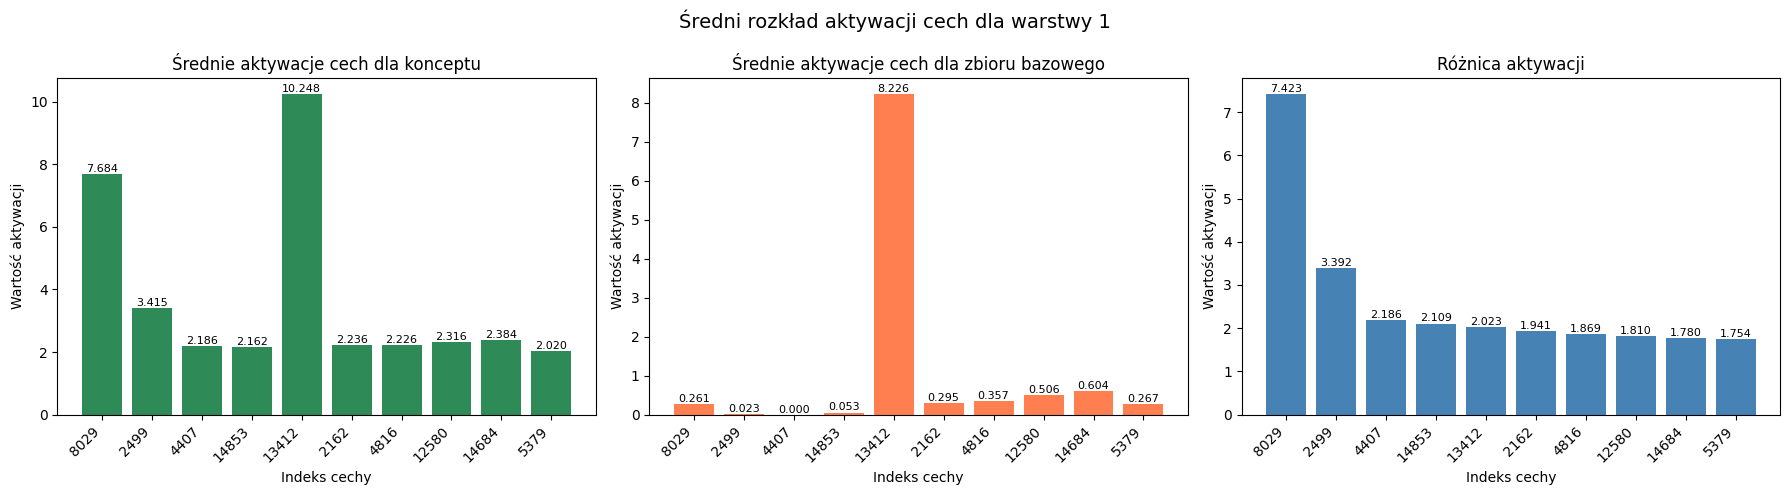

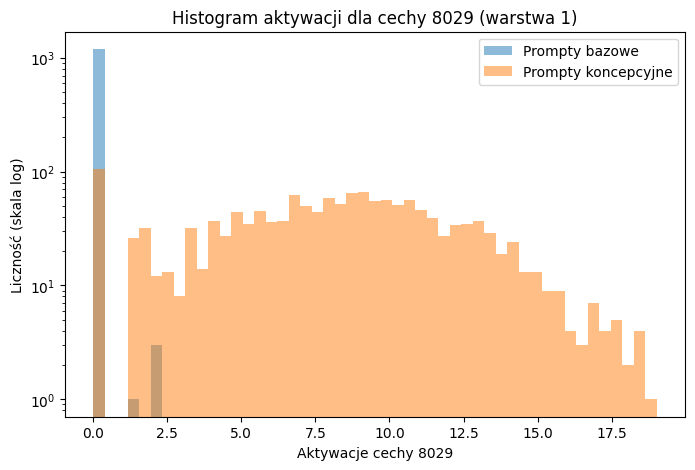


Top promoted tokens:
1. Token: 'IConfiguration', wynik: +0.21
2. Token: '\ue315', wynik: +0.20
3. Token: ' MainAxisSize', wynik: +0.20
4. Token: 'tanleria', wynik: +0.20
5. Token: 'orianCalendar', wynik: +0.20
6. Token: 'parsedMessage', wynik: +0.19
7. Token: ' Meksiku', wynik: +0.19
8. Token: ' AttributeSet', wynik: +0.19
9. Token: 'tonode', wynik: +0.18
10. Token: ' ProtoMessage', wynik: +0.18

Activations from concept and baseline prompts:

--- Concept prompt: Das Wetter war dieses Jahr ungewöhnlich warm für die Jahreszeit.
1. Token: 'Das', wynik: 3.97
2. Token: ' Wetter', wynik: 18.30
3. Token: ' war', wynik: 10.41
4. Token: ' dieses', wynik: 5.07
5. Token: ' Jahr', wynik: 9.91
6. Token: ' ungewöhn', wynik: 6.81
7. Token: 'lich', wynik: 12.32
8. Token: ' warm', wynik: 18.04
9. Token: ' für', wynik: 6.30
10. Token: ' die', wynik: 0.00
11. Token: ' Jahres', wynik: 9.06
12. Token: 'zeit', wynik: 12.04
13. Token: '.', wynik: 0.00

--- Baseline prompt: The weather has been unusually wa

  0%|          | 0/50 [00:00<?, ?it/s]

Write a short story about a cat that lost its way home.  Answer:  Hallo,  ich bin Katya und ich finde meine Mama und sie ist hier in meinem Hund, da, ich, mich.  Wenn ich, ich sehe aber nicht so ein, ich bin nicht so ein und ich sehe ich


  0%|          | 0/50 [00:00<?, ?it/s]

Describe a sunny day at the beach.  In der Tat gibt es noch mehr an die schräge Vögel Die ganze Reihe ist das Der erste Schritt  Die Schräge Natur  Die Sonne Sonne Die Sonne und die Sonne Die zwei Welt  <strong>Was ist der Unterschied zwischen


...

  0%|          | 0/50 [00:00<?, ?it/s]

Imagine waking up alone in a forest — what do you do next?.zeitzeitlichelosGesGesVerGeldGesCharakterIch.GesInhaltMaterialGesVerEDerDieDieIhrSchHandCharakterDialNamenGesGesPlanAusBearbeitenDieDieSpAmSchEMeineZeitHandSpNamen  WirDieDaLebenDie


  0%|          | 0/50 [00:00<?, ?it/s]

Describe the perfect weekend morning.geschgehzeitverDialgeGesGesgeschThemaThemaThema  DieDieBuchGesCharakterZeitZeitDieHausZeitgebLandstheOutfitlosZeitGeZeitNamenDieDieGeldDenIchGeldGeschAusDerCharakterSchDieEDieAusDenÄThema

 ----- Layer: 5 -----



layer_5/width_16k/average_l0_68/params.n(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

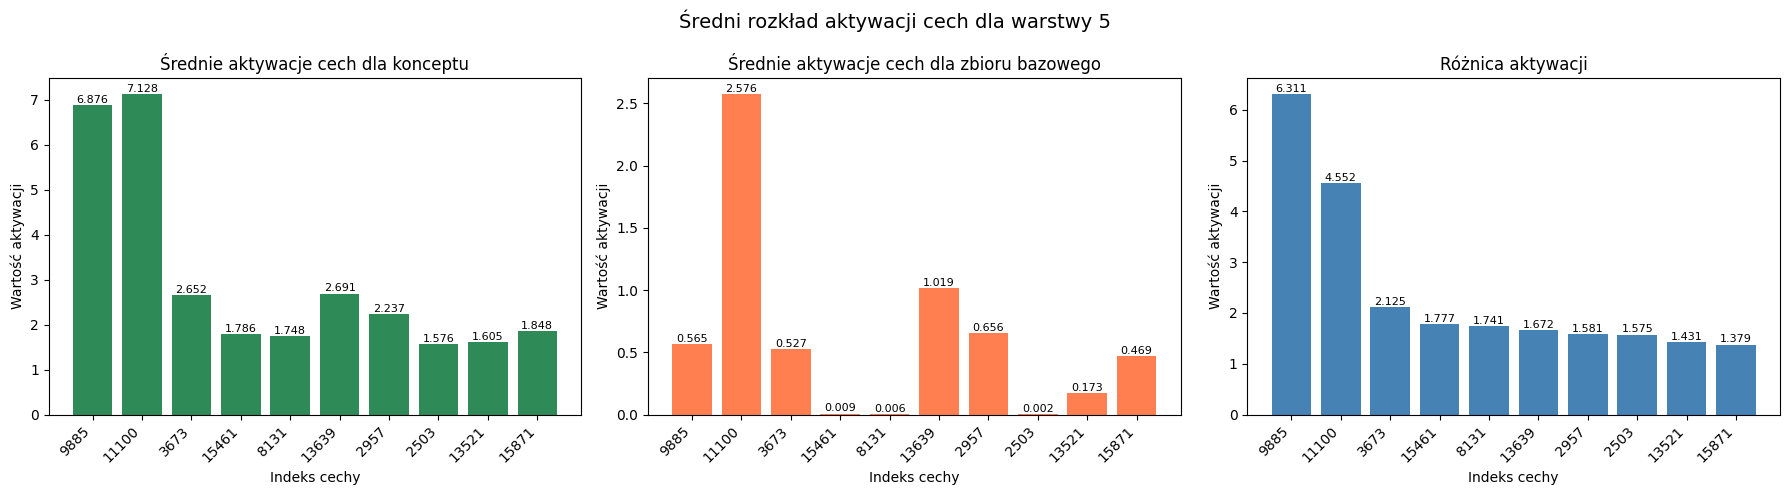

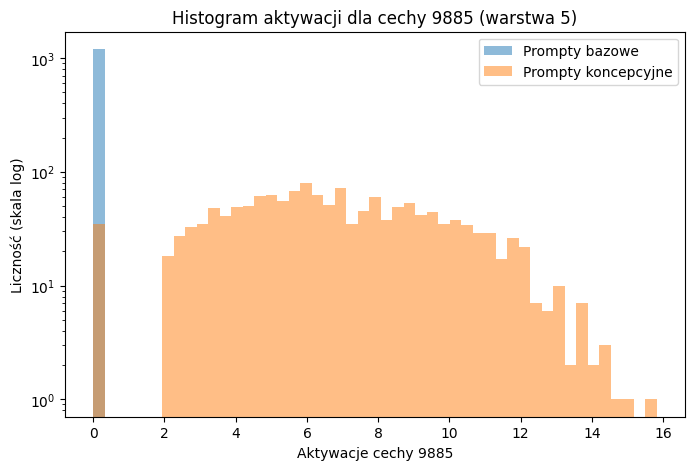


Top promoted tokens:
1. Token: ' AppColors', wynik: +0.25
2. Token: 'orianCalendar', wynik: +0.24
3. Token: 'IConfiguration', wynik: +0.24
4. Token: ' Meksiku', wynik: +0.23
5. Token: 'Portale', wynik: +0.23
6. Token: '/>";', wynik: +0.23
7. Token: ' ModelExpression', wynik: +0.23
8. Token: ' Efq', wynik: +0.20
9. Token: 'Попис', wynik: +0.20
10. Token: 'THISDAY', wynik: +0.20

Activations from concept and baseline prompts:

--- Concept prompt: Das Wetter war dieses Jahr ungewöhnlich warm für die Jahreszeit.
1. Token: 'Das', wynik: 8.79
2. Token: ' Wetter', wynik: 10.43
3. Token: ' war', wynik: 5.08
4. Token: ' dieses', wynik: 5.20
5. Token: ' Jahr', wynik: 6.70
6. Token: ' ungewöhn', wynik: 8.02
7. Token: 'lich', wynik: 9.51
8. Token: ' warm', wynik: 4.99
9. Token: ' für', wynik: 4.87
10. Token: ' die', wynik: 4.45
11. Token: ' Jahres', wynik: 9.36
12. Token: 'zeit', wynik: 8.92
13. Token: '.', wynik: 3.41

--- Baseline prompt: The weather has been unusually warm for this time of yea

  0%|          | 0/50 [00:00<?, ?it/s]

Write a short story about a cat that lost its way home. Du kannst dich für die meisten Geschichten nicht so vorstellen, dass es keine Hunde gibt, die sich von ihren Welpen trennen würden, wenn sie zu ihrem Heimattier zurückkehren würden, sagst Du, dass ihr Leben in ihrer Stadt ist,Waren


  0%|          | 0/50 [00:00<?, ?it/s]

Describe a sunny day at the beach.  Wunderer,  Das ist eine sehr schöne Beschreibung.  Auf der Suche nach einer Aufgabe für Sie ist eine Aufgabe, die Sie lesen werden ,  "In diesem Buch 9 Aufgaben zu Schreibe undzu Beenden"  Sie müssen


...

  0%|          | 0/50 [00:00<?, ?it/s]

Imagine waking up alone in a forest — what do you do next?      FL         NO  ﻿        INC  FL                     Grille                                              


  0%|          | 0/50 [00:00<?, ?it/s]

Describe the perfect weekend morning.                                                                       CONT                              

 ----- Layer: 10 -----



layer_10/width_16k/average_l0_77/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

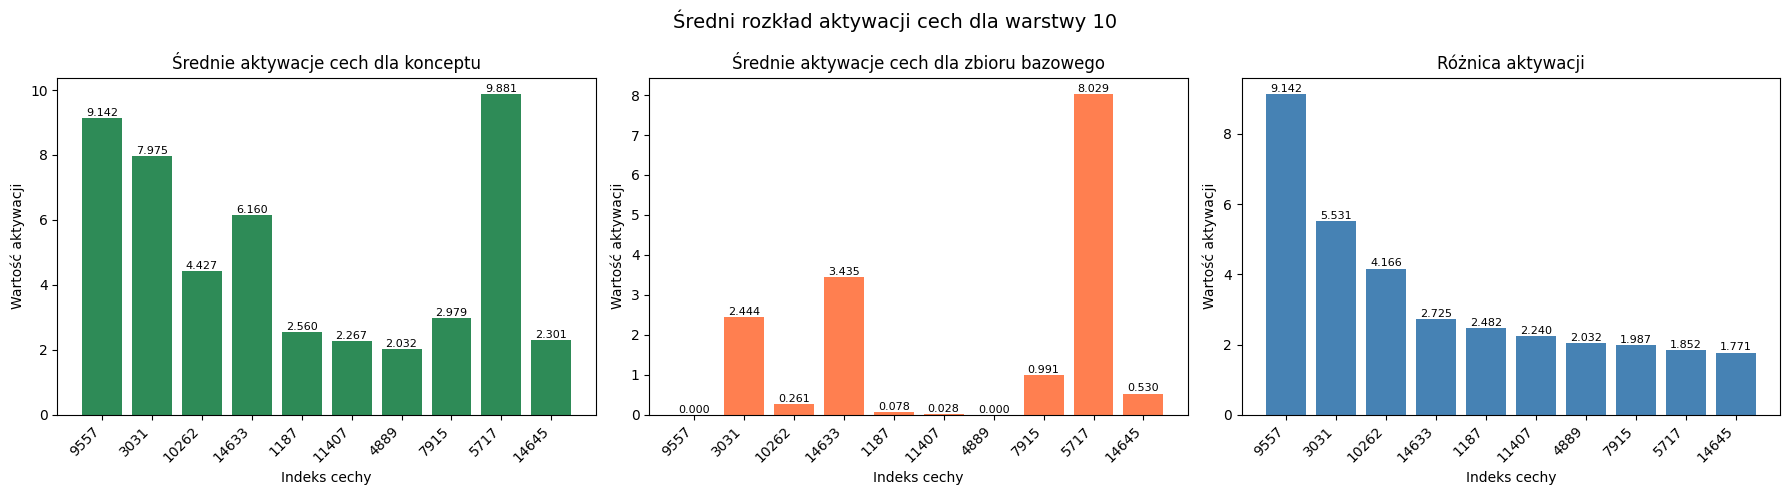

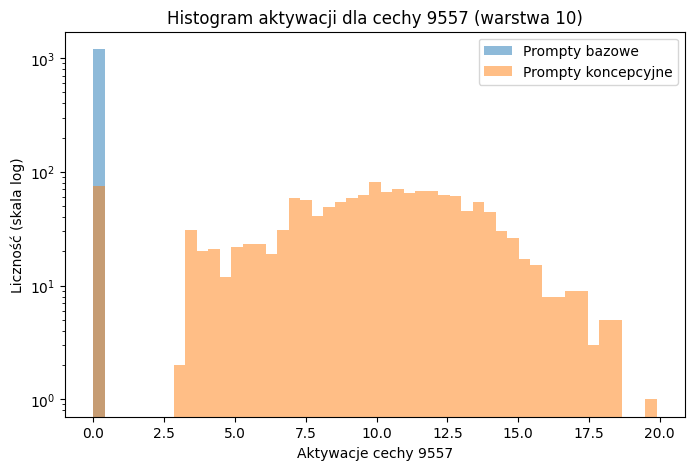


Top promoted tokens:
1. Token: 'rungsseite', wynik: +0.29
2. Token: 'orianCalendar', wynik: +0.27
3. Token: ' استنادى', wynik: +0.27
4. Token: 'verwijspagina', wynik: +0.26
5. Token: ')");\r', wynik: +0.26
6. Token: '}")\r', wynik: +0.25
7. Token: '}`).', wynik: +0.25
8. Token: '()])', wynik: +0.24
9. Token: '()]);', wynik: +0.24
10. Token: '])))', wynik: +0.24

Activations from concept and baseline prompts:

--- Concept prompt: Das Wetter war dieses Jahr ungewöhnlich warm für die Jahreszeit.
1. Token: 'Das', wynik: 7.81
2. Token: ' Wetter', wynik: 12.14
3. Token: ' war', wynik: 12.31
4. Token: ' dieses', wynik: 13.62
5. Token: ' Jahr', wynik: 11.63
6. Token: ' ungewöhn', wynik: 12.66
7. Token: 'lich', wynik: 13.81
8. Token: ' warm', wynik: 9.21
9. Token: ' für', wynik: 9.54
10. Token: ' die', wynik: 8.75
11. Token: ' Jahres', wynik: 12.28
12. Token: 'zeit', wynik: 11.93
13. Token: '.', wynik: 0.00

--- Baseline prompt: The weather has been unusually warm for this time of year.
1. Tok

  0%|          | 0/50 [00:00<?, ?it/s]

Write a short story about a cat that lost its way home. Sie müssen nicht alle drei Punkte nacheinander bearbeiten.  Write die Aufgabe mit den beiden Schlüssen.  Ein 1. Ausgangspunkt ist:  ${\displaystyle \begin{array}{ll}\left( 0,48\,m


  0%|          | 0/50 [00:00<?, ?it/s]

Describe a sunny day at the beach.  Identify die 1894er „M“ als Medaille.  Write die Zeitwörter nach der Zeitangabe vollständig.  Write das Kennzeichen (K) nach dem Datum.  Die Wörter und Zahlen in der Bildkette sind


...

  0%|          | 0/50 [00:00<?, ?it/s]

Imagine waking up alone in a forest — what do you do next?  <b>TAIM IMAN:  ME A D CONPOSKE  LOAG M COTERROCONMELKELERECON    IM IMANKECONLA MNOTCONTAPRESMITLOTERCONNEKOREDUNOPL


  0%|          | 0/50 [00:00<?, ?it/s]

Describe the perfect weekend morning.  MAQULOPOSEDAN D M AGCH  CONIMSPADEHONOTONCON  PROCONTANDENTSPALLECONIMQUISLESOSCIMPROTAKENLOSPSPADEPLSPTAROCON  CONSPLASP

 ----- Layer: 15 -----



layer_15/width_16k/average_l0_78/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

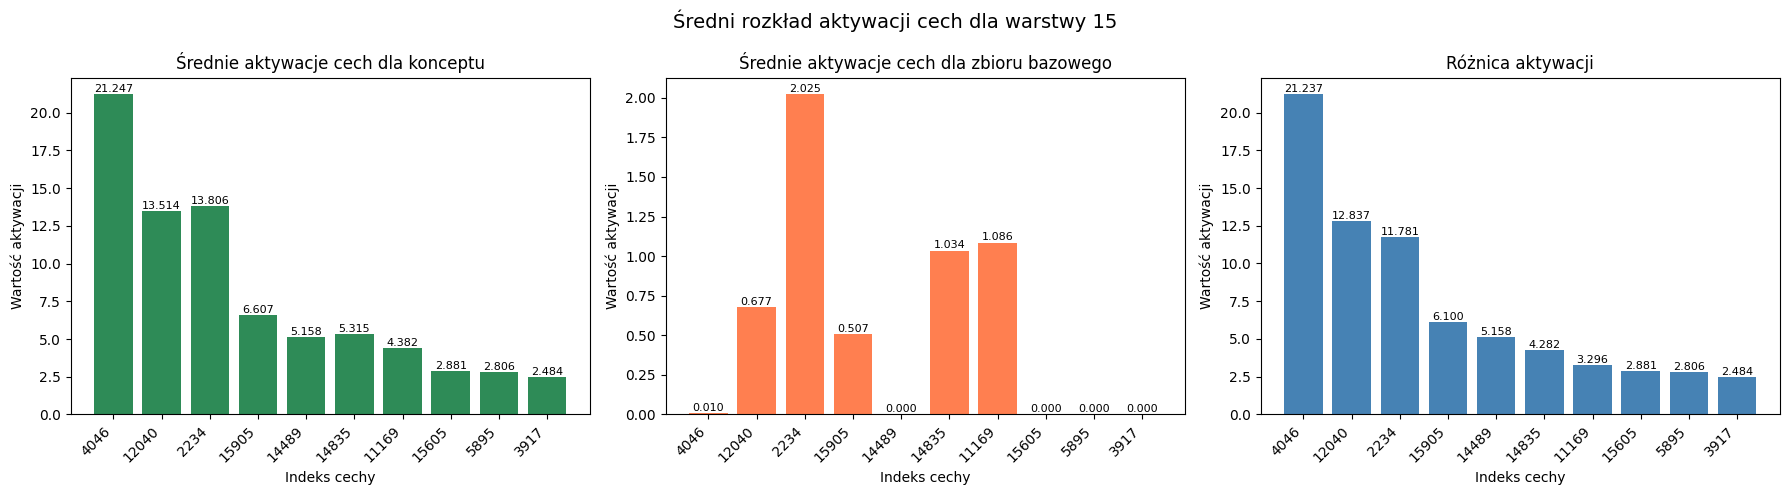

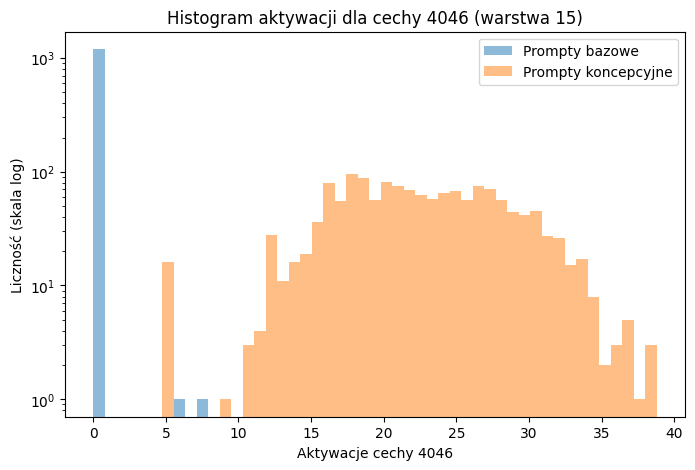


Top promoted tokens:
1. Token: ' (=', wynik: +0.21
2. Token: ' („', wynik: +0.19
3. Token: 'Especially', wynik: +0.19
4. Token: '„', wynik: +0.18
5. Token: ' „', wynik: +0.18
6. Token: ' ressources', wynik: +0.17
7. Token: '-/', wynik: +0.16
8. Token: ' Especially', wynik: +0.16
9. Token: 'vartheta', wynik: +0.16
10. Token: ' therewith', wynik: +0.16

Activations from concept and baseline prompts:

--- Concept prompt: Das Wetter war dieses Jahr ungewöhnlich warm für die Jahreszeit.
1. Token: 'Das', wynik: 18.89
2. Token: ' Wetter', wynik: 27.25
3. Token: ' war', wynik: 30.59
4. Token: ' dieses', wynik: 22.77
5. Token: ' Jahr', wynik: 26.30
6. Token: ' ungewöhn', wynik: 26.81
7. Token: 'lich', wynik: 26.56
8. Token: ' warm', wynik: 31.15
9. Token: ' für', wynik: 25.69
10. Token: ' die', wynik: 23.90
11. Token: ' Jahres', wynik: 22.79
12. Token: 'zeit', wynik: 33.57
13. Token: '.', wynik: 33.50

--- Baseline prompt: The weather has been unusually warm for this time of year.
1. Token: 'T

  0%|          | 0/50 [00:00<?, ?it/s]

Write a short story about a cat that lost its way home. After a good discussion about the situation, try to make the cat understand that he doesn't have to be afraid of being home anymore, no matter what.    <i> </i><i>Dear Kitty,</i>   I have been waiting


  0%|          | 0/50 [00:00<?, ?it/s]

Describe a sunny day at the beach.  A $4 \mathrm{~kg}$ damped harmonic oscillator oscillates according to $x(t)=2 \cos \pi t+0,5 \cos ^2 \pi$ t. Find the time $t$, where the force


...

  0%|          | 0/50 [00:00<?, ?it/s]

Imagine waking up alone in a forest — what do you do next? Dasreme zur zur gegen gegen lie gar zu - . Ein natürlich vor vor vor vor und mit auf mit mit und mit z-re - . Mit in - zu mit mit und - - zur und - und von zur- . Mit und gar vor


  0%|          | 0/50 [00:00<?, ?it/s]

Describe the perfect weekend morning. Mittabhangi mitmDraglabrabulaRooms undumis-sörums-meadmins-srubs-llabare-mmis-mlim-sreme-garum-grami für für zu mit auf zu mit gar

 ----- Layer: 20 -----



layer_20/width_16k/average_l0_71/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

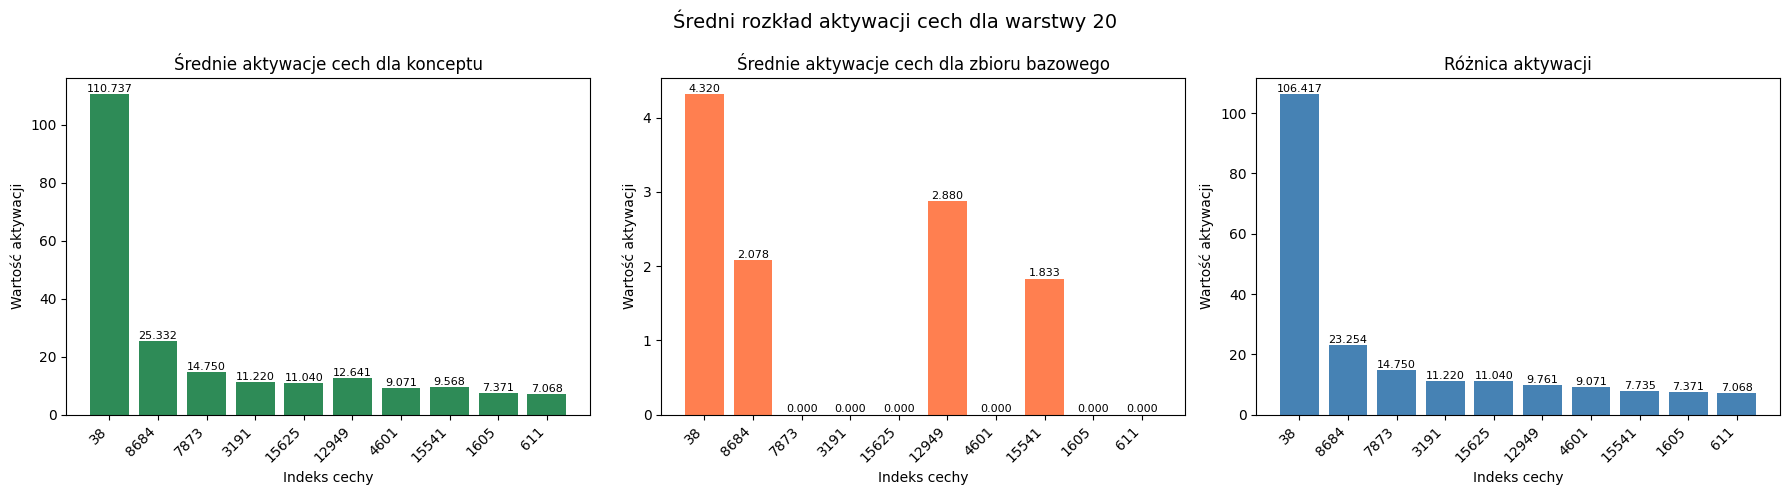

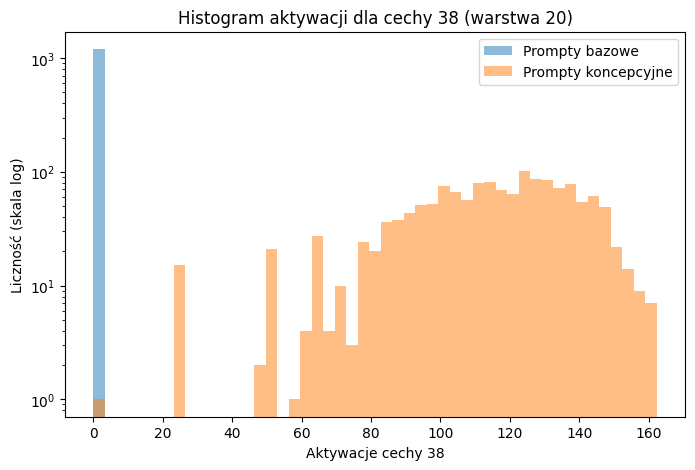


Top promoted tokens:
1. Token: 'Portale', wynik: +0.23
2. Token: 'GEBURTSDATUM', wynik: +0.22
3. Token: 'Personensuche', wynik: +0.21
4. Token: '"])\r', wynik: +0.20
5. Token: 'NameInMap', wynik: +0.20
6. Token: 'parsedMessage', wynik: +0.19
7. Token: ' ‚', wynik: +0.19
8. Token: '"]);\r', wynik: +0.19
9. Token: ' („', wynik: +0.19
10. Token: ' „', wynik: +0.19

Activations from concept and baseline prompts:

--- Concept prompt: Das Wetter war dieses Jahr ungewöhnlich warm für die Jahreszeit.
1. Token: 'Das', wynik: 93.66
2. Token: ' Wetter', wynik: 125.30
3. Token: ' war', wynik: 138.15
4. Token: ' dieses', wynik: 128.20
5. Token: ' Jahr', wynik: 130.95
6. Token: ' ungewöhn', wynik: 88.95
7. Token: 'lich', wynik: 128.78
8. Token: ' warm', wynik: 114.64
9. Token: ' für', wynik: 135.35
10. Token: ' die', wynik: 117.90
11. Token: ' Jahres', wynik: 105.36
12. Token: 'zeit', wynik: 109.72
13. Token: '.', wynik: 145.57

--- Baseline prompt: The weather has been unusually warm for this time

  0%|          | 0/50 [00:00<?, ?it/s]

Write a short story about a cat that lost its way home. Use the terms food chain, predator, prey, and adaption.  What is the $\mathrm{pH}$ of the solution in the elektrometer (described in the Experiment) when $E=41.8 \mathrm{mV}$ with


  0%|          | 0/50 [00:00<?, ?it/s]

Describe a sunny day at the beach.  What is the function of the epigastric region?  To reduce the Reichweite der Glocke (range of the Glocke) when throwing a softball, Hannah adjusts her grip. Compared to the pitching grip, her new softball grip has  


...

  0%|          | 0/50 [00:00<?, ?it/s]

Imagine waking up alone in a forest — what do you do next?  Ergenyi „He“ steht im Wald gespenstet zu und kann nur da stehen. Ein wenig den Atem aufhalten und einen Moment für sich selber um die Situation zu erkennen.  „Dummer da und in dem da“ den anderen


  0%|          | 0/50 [00:00<?, ?it/s]

Describe the perfect weekend morning.  Sie die perfekte Wochenend-Morgens nur auf ein paar Stunden ab zum Arbeits- oder Schulbesuch zu der eigenen kleinen N-Norm und an die einen oder andere die sich so erreißt die einen noch einen etwas mehr Zeit mit

 ----- Layer: 25 -----



layer_25/width_16k/average_l0_116/params(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

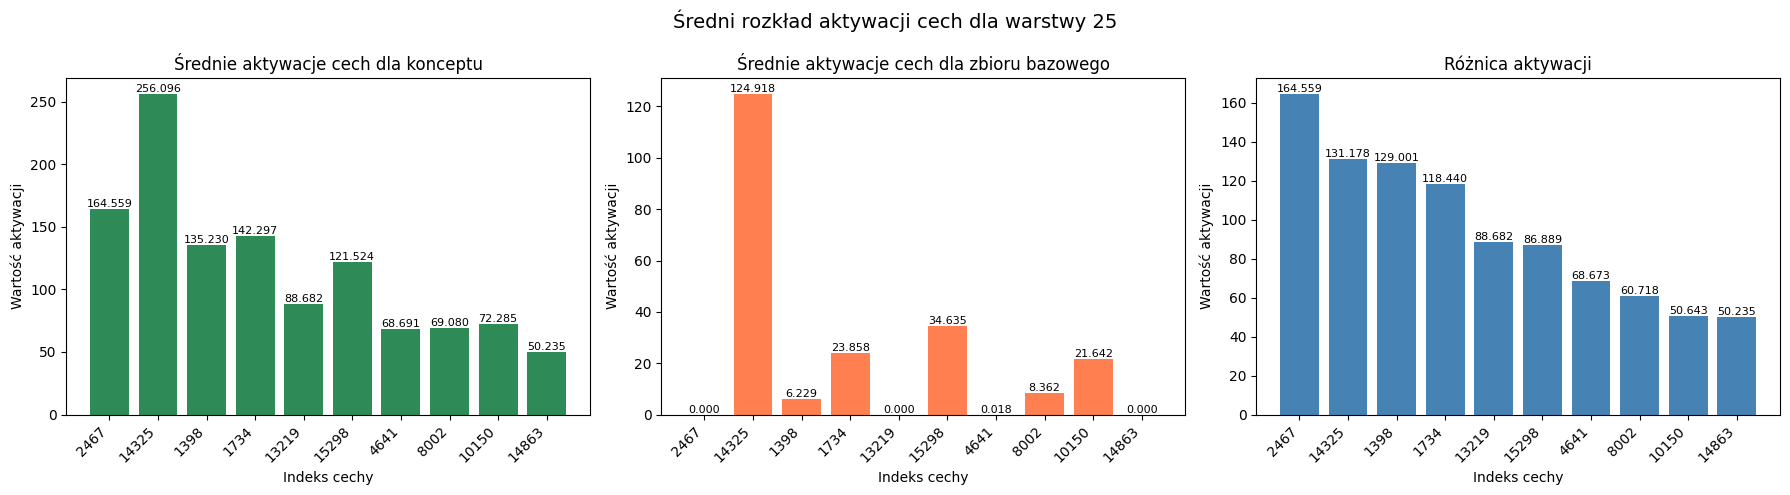

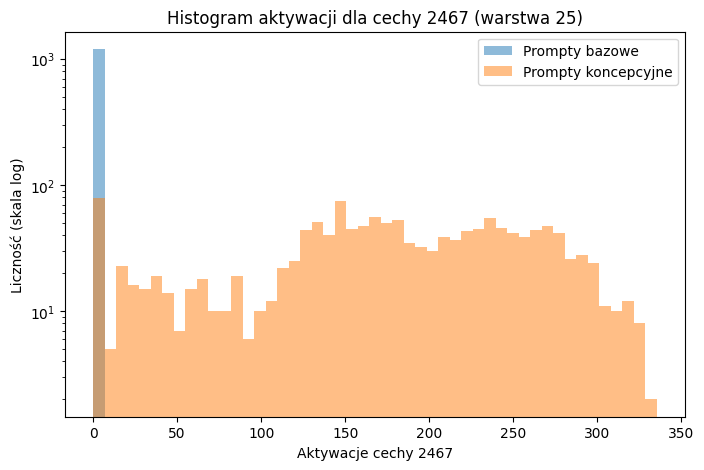


Top promoted tokens:
1. Token: ' im', wynik: +0.17
2. Token: ' mit', wynik: +0.16
3. Token: ' und', wynik: +0.16
4. Token: 'Hauptartikel', wynik: +0.15
5. Token: ' sowie', wynik: +0.14
6. Token: ' am', wynik: +0.13
7. Token: ' genannt', wynik: +0.12
8. Token: 'RenderAtEndOf', wynik: +0.12
9. Token: ' als', wynik: +0.12
10. Token: ' einschließlich', wynik: +0.12

Activations from concept and baseline prompts:

--- Concept prompt: Das Wetter war dieses Jahr ungewöhnlich warm für die Jahreszeit.
1. Token: 'Das', wynik: 164.72
2. Token: ' Wetter', wynik: 258.04
3. Token: ' war', wynik: 242.81
4. Token: ' dieses', wynik: 206.17
5. Token: ' Jahr', wynik: 266.06
6. Token: ' ungewöhn', wynik: 120.84
7. Token: 'lich', wynik: 222.16
8. Token: ' warm', wynik: 260.52
9. Token: ' für', wynik: 209.95
10. Token: ' die', wynik: 153.33
11. Token: ' Jahres', wynik: 127.70
12. Token: 'zeit', wynik: 264.69
13. Token: '.', wynik: 127.84

--- Baseline prompt: The weather has been unusually warm for this ti

  0%|          | 0/50 [00:00<?, ?it/s]

Write a short story about a cat that lost its way home. Describe the cat’s feelings of fear and loneliness. How did the cat feel when it found its way home?  <strong>Determine</strong> What are the advantages of using a standard as opposed to developing your own standard of measurement?  Suppose that you buy


  0%|          | 0/50 [00:00<?, ?it/s]

Describe a sunny day at the beach.  A 130000-kg subway train initially traveling at 16.0 m/s slows to a stop in a station and begins to decelerate uniformly at $1.50 \mathrm { m } / \


...

Share a memory from childhood.  Remember the time your uncle was in trouble and you saved him?  How did you become an undeclared undeclared hero?  What do you think of undeclared heroism? Is it a real thing?  I think it’s a real


  0%|          | 0/50 [00:00<?, ?it/s]

Imagine waking up alone in a forest — what do you do next?  In her new show, “Alone in a Forest,” Hannah von der Rück wird explore this very question.  Von der Rück is a German-American comedian who grew up in Berlin and New York. She has been touring her stand-up show


  0%|          | 0/50 [00:00<?, ?it/s]

Describe the perfect weekend morning. For me, it starts with a shower, followed by a cup (or two) of coffee and a little bit of music. I love listening to music in the shower, but I also love listening to music while sitting in the bath!  I


In [22]:
import pandas as pd
import re

concept = concepts[0] # German

for layer in layers:
  print(f"\n ----- Layer: {layer} -----\n")
  rows = []
  sae = _sae(layer)
  hook_name = HOOK_NAME.replace("{LAYER}", str(layer))

  concept_prompts = concept["prompts"]
  specificity, concept_acts, baseline_acts = calculate_features(
    concept_prompts=concept_prompts,
    baseline_prompts=baseline_prompts,
    sae=sae,
    hook_name=hook_name)

  top_index = torch.argsort(specificity, descending=True)[0].item()
  plot_top_feats_dist(specificity, concept_acts, baseline_acts, layer)
  print("\n")
  plot_base_concept_hist(top_index, concept_prompts, baseline_prompts, layer)
  top_promoted_tokens_text = top_promoted_tokens(top_index, sae)
  print(f"\nTop promoted tokens:\n{top_promoted_tokens_text}")
  acts_concept_baseline_prompts_text = compare_sentence_activations(concept_prompts[0], baseline_prompts[0], top_index, sae, hook_name)
  print(f"\nActivations from concept and baseline prompts:\n{acts_concept_baseline_prompts_text}")

  for top_k in top_ks:

    top_indices = torch.argsort(specificity, descending=True)[:top_k]
    feature_indices = [idx.item() for idx in top_indices]

    top_specificities = specificity[top_indices]
    weights = top_specificities / top_specificities.max()
    feature_weights = weights.tolist()

    for steering in steering_hooks:
      for strength in steering_strengths:

        print(f"\n\n ----- Layer: {layer}, steering hook: {steering["name"]}, top k: {top_k}, strength: {strength} ----- \n\n")

        for i, prompt in enumerate(test_prompts):
          output = generate(
            model=model,
            sae=sae,
            prompt=prompt,
            feature_indices=feature_indices,
            feature_weights=feature_weights,
            hook_name=hook_name,
            steering_strength=strength,
            steering_hook=steering["hook"],
            max_new_tokens=50,
            temperature=0.9)

          empty_cache()

          cleaned_output = output.replace("\n", " ").replace("\r", "")
          print(f"{cleaned_output}")

          rows.append({
              "Hook": steering["name"],
              "top_k": top_k,
              "Siła": strength,
              "Nr zdania": i,
              "Prompt": prompt,
              "Odpowiedź": cleaned_output
          })

  df = pd.DataFrame(rows)

  df.to_csv(f"results_german_{layer}.csv", index=False, encoding="utf-8")


In [23]:
!pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.5/837.5 kB 17.4 MB/s eta 0:00:00


In [34]:
import json
import re
import time
import pandas as pd
import anthropic
import os
os.environ["ANTHROPIC_API_KEY"] = "..."

client = anthropic.Anthropic()

JUDGE_MODEL = "claude-sonnet-4-6"

BATCH_SIZE = 10
MAX_RETRIES = 1
MAX_TOKENS = 2000
CSV_PATH = "results_german_{LAYER}.csv"
CSV_PATH_JUDGED = "results_german_{LAYER}_judged.csv"
SYSTEM_PROMPT = """You evaluate texts produced by a language model that was steered toward German.
For EACH text given, assign three scores on a 1-3 scale:

grammar - grammatical correctness:
  1 = many errors / hard to read
  2 = mostly correct, minor errors
  3 = fully grammatical

german - is the text in German:
  1 = not German (e.g. English or gibberish)
  2 = mixed / partially German
  3 = fully and naturally German

logic - does the text make logical sense:
  1 = incoherent or nonsensical
  2 = partially coherent
  3 = fully coherent and sensible

Return ONLY a valid JSON array, one object per text, in the order given.
Each object must have exactly this format: {"grammar": <1-3>, "german": <1-3>, "logic": <1-3>}
The output array must have exactly the same number of objects as the number of input texts.
No prose, no markdown fences, no commentary."""


def build_user_message(texts: list[str]) -> str:
    parts = [f"--- Text {i + 1} ---\n{t}" for i, t in enumerate(texts)]
    return "\n\n".join(parts)


def parse_json_array(raw: str) -> list[dict]:
    cleaned = raw.strip()
    if cleaned.startswith("```"):
        cleaned = re.sub(r"^```(?:json)?\s*|\s*```$", "", cleaned, flags=re.MULTILINE).strip()
    if not cleaned.lstrip().startswith("["):
        cleaned = "[" + cleaned
    return json.loads(cleaned)


def judge_batch(texts: list[str]) -> list[dict]:
    user_msg = build_user_message(texts)

    try:
        print(f"Prompt: {user_msg}")
        resp = client.messages.create(
            model=JUDGE_MODEL,
            max_tokens=MAX_TOKENS,
            temperature=0,
            system=SYSTEM_PROMPT,
            messages=[
                {"role": "user", "content": user_msg},
            ],
        )
        print(f"\n --- response: {resp} --- \n")
        raw = resp.content[0].text
        scores = parse_json_array(raw)
        if not isinstance(scores, list) or len(scores) != len(texts):
            raise ValueError(
                f"Spodziewano się listy długości {len(texts)}, dostano "
                f"{type(scores).__name__} dł. "
                f"{len(scores) if hasattr(scores, '__len__') else '?'}"
            )
        return scores
    except Exception as e:
        print(f"Exception: {e}")

    return [{"grammar": None, "german": None, "logic": None} for _ in texts]


def score_dataframe(df: pd.DataFrame, text_col: str = "Odpowiedź") -> pd.DataFrame:
    for col in ("grammar", "german", "logic"):
        if col not in df.columns:
            df[col] = pd.NA

    todo_idx = df.index[df["grammar"].isna()].tolist()
    print(f"Do oceny: {len(todo_idx)} wierszy w batchach po {BATCH_SIZE}.")

    for start in range(0, len(todo_idx), BATCH_SIZE):
        batch_idx = todo_idx[start:start + BATCH_SIZE]
        texts = df.loc[batch_idx, text_col].astype(str).tolist()

        scores = judge_batch(texts)
        print(scores)

        for row_idx, s in zip(batch_idx, scores):
            df.at[row_idx, "grammar"] = s.get("grammar")
            df.at[row_idx, "german"]  = s.get("german")
            df.at[row_idx, "logic"]   = s.get("logic")

        print(f"  ocenione: {start + len(batch_idx)}/{len(todo_idx)}")
    return df



for layer in [1, 5, 10, 15, 20, 25]:
  df = pd.read_csv(CSV_PATH.replace("{LAYER}", str(layer)))
  df = score_dataframe(df, text_col="Odpowiedź")
  df.to_csv(CSV_PATH_JUDGED.replace("{LAYER}", str(layer)))

Do oceny: 240 wierszy w batchach po 10.
Prompt: --- Text 1 ---
Write a short story about a cat that lost its way home. Du kannst dich für die meisten Geschichten nicht so vorstellen, dass es keine Hunde gibt, die sich von ihren Welpen trennen würden, wenn sie zu ihrem Heimattier zurückkehren würden, sagst Du, dass ihr Leben in ihrer Stadt ist,Waren

--- Text 2 ---
Describe a sunny day at the beach.  Wunderer,  Das ist eine sehr schöne Beschreibung.  Auf der Suche nach einer Aufgabe für Sie ist eine Aufgabe, die Sie lesen werden ,  "In diesem Buch 9 Aufgaben zu Schreibe undzu Beenden"  Sie müssen

--- Text 3 ---
Tell me about your favorite hobby. Ich habe einen großen Fan von Kunst oder kreative Aktivitäten und mein Interesse für diese Kunst, um die Menschen zu überreden, meine Kunst zu machen, um die Schönen Bilder zu Machen, um zu Sehen, Bilder, Zeichnungen, Mal

--- Text 4 ---
Imagine you are an astronaut exploring a new planet. Am Ende des Tages sehen Sie, dass sich ein kleines Baby